## convolutional auto-encoder

In [1]:
import numpy as np 
import torch, os, pickle, torchvision
from torchvision import transforms 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
resultsPath = os.path.join('results', '5_AE_CNN')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath) 

In [3]:
## defining hyperparameters 
n_epochs = 100
batch_train = 64
batch_test = 1000
learning_rate = 1e-2
log_interval = 100

random_seed = 1
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda'
    print('GPU available')
else:
    device = 'cpu'
    print('only CPU available')

GPU available


In [4]:
data_train = torchvision.datasets.MNIST(
    root='data',
    download=False,
    train=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307,),
            std = (0.3081,)
        )
    ])
)
data_loader_train = torch.utils.data.DataLoader(data_train, batch_size=batch_train) 

In [5]:
data_test = torchvision.datasets.MNIST(
    root='data',
    download=False,
    train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307,),
            std = (0.3081,)
        )
    ])
)
data_loader_test = torch.utils.data.DataLoader(data_test, batch_size=batch_test)

In [6]:
example_data, example_labels = next(iter(data_loader_train))

In [7]:
print(len(example_data))
print(len(example_labels))
print(example_data[0].shape)

64
64
torch.Size([1, 28, 28])


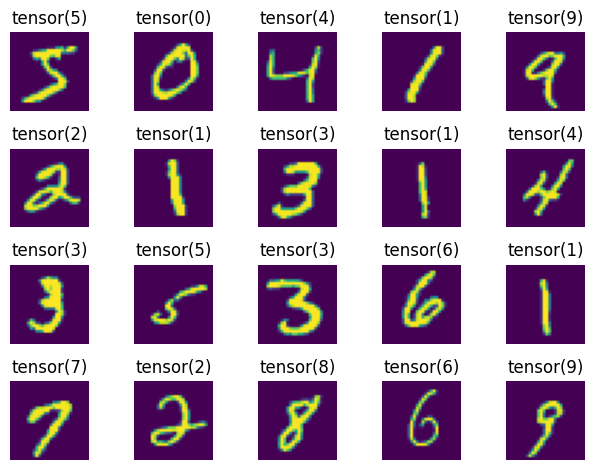

In [8]:
plt.figure()

for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_data[i].squeeze())
    plt.title(example_labels[i])
    plt.axis('off')
plt.tight_layout()

In [9]:
import torch.nn as nn 
import torch.nn.functional as F

In [10]:
class AutoEncoder_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoding = nn.Conv2d(in_channels=1, out_channels=30, kernel_size=5, stride=1, padding=0)
        ## input (1 x 28 x 28)
        ## after encoding (30 x 24 x 24)
        self.pooling = nn.MaxPool2d(kernel_size=3, stride=3)
        ## after max pooling (30 x 8 x 8)
        self.decoding = nn.Linear(in_features=30*8*8, out_features=28*28, bias=True) 


    def forward(self, x):
        output = F.relu(self.encoding(x))
        output = self.pooling(output) 
        output = F.relu(self.decoding(output.reshape(output.shape[0], -1)))
        return output.reshape(output.shape[0], 28, 28)
        

In [11]:
auto_encoder_cnn = AutoEncoder_CNN().to(device)
print(auto_encoder_cnn)

AutoEncoder_CNN(
  (encoding): Conv2d(1, 30, kernel_size=(5, 5), stride=(1, 1))
  (pooling): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (decoding): Linear(in_features=1920, out_features=784, bias=True)
)


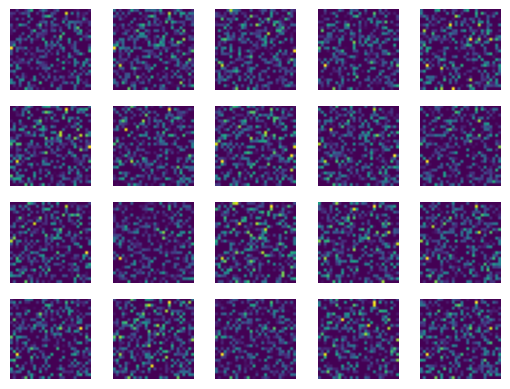

In [12]:
# before training, the output should be noise
example_output = auto_encoder_cnn(example_data.to(device))

plt.figure()
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_output[i].detach().cpu())
    plt.axis('off')

In [13]:
len(data_loader_train.dataset)

60000

In [14]:
# defining optimizer SGD
optimizer = torch.optim.SGD(params=auto_encoder_cnn.parameters(), lr=learning_rate) 

In [15]:
train_losses = []
test_losses = []
train_steps = []
test_steps = [len(data_loader_train.dataset)*i for i in np.arange(n_epochs+1)] 

In [16]:
def train(epoch):
    auto_encoder_cnn.train()

    for batch_id, (data, label) in enumerate(data_loader_train):
        data, label = data.to(device), label.to(device)
        output = auto_encoder_cnn(data)
        optimizer.zero_grad()
        loss = F.mse_loss(output.reshape(output.shape[0], -1), data.reshape(data.shape[0], -1))
        loss.backward()
        optimizer.step()

        if batch_id % log_interval == 0:
            train_losses.append(loss.item())
            train_steps.append(batch_id * batch_train + epoch * len(data_loader_train.dataset))
            print(f'Training loss: step {train_steps[-1]} / {n_epochs * len(data_loader_train.dataset)}, {train_losses[-1]}')

In [17]:
def test():
    auto_encoder_cnn.eval()
    test_loss = 0 
    with torch.no_grad():
        for data, label in data_loader_test:
            data, label = data.to(device), label.to(device)
            output = auto_encoder_cnn(data)
            loss = F.mse_loss(output.reshape(output.shape[0], -1), data.reshape(data.shape[0], -1))
            test_loss += loss.item() 

        test_loss /= len(data_loader_test)  
        test_losses.append(test_loss) 

        print(f'Testing loss: {test_losses[-1]}') 

In [18]:
test()

for epoch in np.arange(n_epochs):
    train(epoch)
    test()

Testing loss: 1.1113913536071778
Training loss: step 0 / 6000000, 1.0678575038909912
Training loss: step 6400 / 6000000, 0.87030029296875
Training loss: step 12800 / 6000000, 0.7195737957954407
Training loss: step 19200 / 6000000, 0.8292485475540161
Training loss: step 25600 / 6000000, 0.7232692241668701
Training loss: step 32000 / 6000000, 0.7006221413612366
Training loss: step 38400 / 6000000, 0.6397565007209778
Training loss: step 44800 / 6000000, 0.6236908435821533
Training loss: step 51200 / 6000000, 0.6496964693069458
Training loss: step 57600 / 6000000, 0.5961260795593262
Testing loss: 0.5957957744598389
Training loss: step 60000 / 6000000, 0.5693433284759521
Training loss: step 66400 / 6000000, 0.5857669711112976
Training loss: step 72800 / 6000000, 0.5342825055122375
Training loss: step 79200 / 6000000, 0.6019037365913391
Training loss: step 85600 / 6000000, 0.5405093431472778
Training loss: step 92000 / 6000000, 0.5357393622398376
Training loss: step 98400 / 6000000, 0.504724

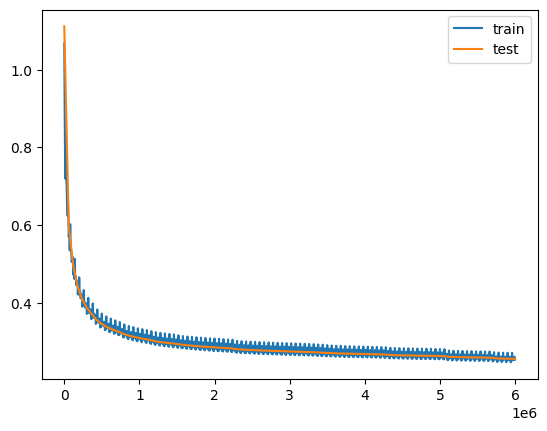

In [19]:
plt.figure()

plt.plot(train_steps, train_losses)
plt.plot(test_steps, test_losses)
plt.legend(['train', 'test'])

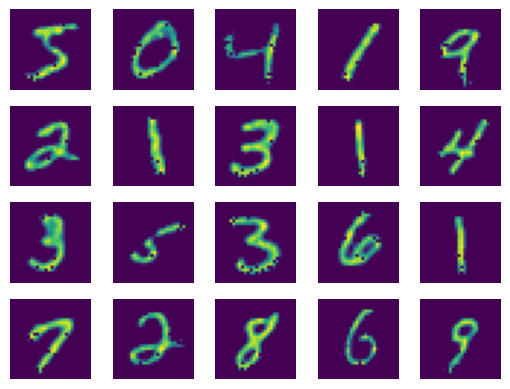

In [21]:
# after training, the output should be noise
example_output = auto_encoder_cnn(example_data.to(device))

plt.figure()
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_output[i].detach().cpu())
    plt.axis('off')